# 서비스 기획 3W
#### 1. Why
- 왜 이 서비스가 필요한가? 어떤 문제를 해결하려는가?
- 데이터 분석(시나리오 및 가설 설정, 가설 검증, 인사이트 도출)을 통해 왜 이 서비스가 필요한지 정의
#### 2. Who
- 이 서비스를 이용할 핵심 고객은 누구인가?
- 페르소나 설정
#### 3. What
- 문제를 해결하기 위해 어떤 서비스와 기능을 제공할 것인가?
- 사용자의 문제를 해결할 수 있는 핵심 가치와 구체적인 서비스 기능을 도출

### 데이터 불러오기

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_csv('data/Developer Salary.csv', encoding='cp949') 

# 인코딩 파라미터 없이도 파일을 불러올 수 있지만 인코딩 방식을 적어주는 것이 좋음
# 한글이 포함되어 있는 데이터이지만 utf-8로 인코딩 가능
data

,일련번호,나이,학력,성별,정신건강,전문직,개발공부기간,연차,국적,연봉,보유기술개수
0,DEV1,<35,Master,Man,No,Dev,15,6,Germany,77290,7
1,DEV2,<35,Undergraduate,Man,No,Dev,9,6,Canada,46135,13
2,DEV3,>35,Master,Man,No,Dev,26,18,Germany,77831,17
3,DEV4,>35,Undergraduate,Man,No,Dev,39,21,United Kingdom of Great Britain and Northern I...,68507,3
4,DEV5,<35,Master,Man,No,Dev,19,10,Germany,60535,5
...,...,...,...,...,...,...,...,...,...,...,...
33461,DEV33462,<35,Master,Man,Yes,Dev,7,5,United States of America,94000,5
33462,DEV33463,<35,Undergraduate,Man,No,Dev,7,2,Germany,41058,13
33463,DEV33464,>35,Undergraduate,Man,No,Dev,21,16,United States of America,115000,11
33464,DEV33465,<35,Undergraduate,Man,Yes,Dev,5,1,United States of America,70000,15


In [9]:
data.set_index('일련번호', inplace=True)

data

,나이,학력,성별,정신건강,전문직,개발공부기간,연차,국적,연봉,보유기술개수
일련번호,,,,,,,,,,
DEV1,<35,Master,Man,No,Dev,15,6,Germany,77290,7
DEV2,<35,Undergraduate,Man,No,Dev,9,6,Canada,46135,13
DEV3,>35,Master,Man,No,Dev,26,18,Germany,77831,17
DEV4,>35,Undergraduate,Man,No,Dev,39,21,United Kingdom of Great Britain and Northern I...,68507,3
DEV5,<35,Master,Man,No,Dev,19,10,Germany,60535,5
...,...,...,...,...,...,...,...,...,...,...
DEV33462,<35,Master,Man,Yes,Dev,7,5,United States of America,94000,5
DEV33463,<35,Undergraduate,Man,No,Dev,7,2,Germany,41058,13
DEV33464,>35,Undergraduate,Man,No,Dev,21,16,United States of America,115000,11


In [10]:
# [결측치 및 이상치 처리]

# 1. 결측치 처리 (평균으로 대체)
mean_salary = data['연봉'].mean()
mean_skills = data['보유기술개수'].mean()

data['연봉'] = data['연봉'].fillna(mean_salary)
data['보유기술개수'] = data['보유기술개수'].fillna(mean_skills)

In [11]:
# 결측치 처리 됐는지 확인
data.isnull().sum()

나이        0
학력        0
성별        0
정신건강      0
전문직       0
개발공부기간    0
연차        0
국적        0
연봉        0
보유기술개수    0
dtype: int64

In [12]:
# 2. 이상치 처리
# 연봉 이상치
salary_mean = data['연봉'].median()

# 사분위수 계산
Q1_salary = data['연봉'].quantile(0.25)
Q3_salary = data['연봉'].quantile(0.75)

# 사분위 범위 계산
IQR_salary = Q3_salary - Q1_salary
lower_salary = Q1_salary - 1.5 * IQR_salary
upper_salary = Q3_salary + 1.5 * IQR_salary
print(len(data.loc[(data['연봉'] < lower_salary) | (data['연봉'] > upper_salary), '연봉'] ))
data.loc[(data['연봉'] < lower_salary) | (data['연봉'] > upper_salary), '연봉'] = salary_mean
print(len(data.loc[(data['연봉'] < lower_salary) | (data['연봉'] > upper_salary), '연봉'] ))

0
0


In [13]:
# 보유기술개수 이상치
skill_mean = data['보유기술개수'].median()

# 연봉 이상치
Q1_skill = data['보유기술개수'].quantile(0.25)
Q3_skill = data['보유기술개수'].quantile(0.75)

# 사분위 범위 계산
IQR_skill = Q3_skill - Q1_skill
lower_skill = Q1_skill - 1.5 * IQR_skill
upper_skill = Q3_skill + 1.5 * IQR_skill

print(len(data.loc[(data['보유기술개수'] < lower_skill) | (data['보유기술개수'] > upper_skill), '보유기술개수']))
data.loc[(data['보유기술개수'] < lower_skill) | (data['보유기술개수'] > upper_skill), '보유기술개수'] = skill_mean
print(len(data.loc[(data['보유기술개수'] < lower_skill) | (data['보유기술개수'] > upper_skill), '보유기술개수']))

618
0


### 데이터 연산

In [14]:
# 컬럼 인덱싱
# df[컬럼명]

# DataFrame 및 Series는 배열로 구성되어 있기 때문에 숫자적인 연산이 가능하다!
# 기존 DataFrame에 새로운 컬럼을 추가하려면 없는 컬럼에 접근한 뒤, 대입연산자로 새로운 데이터를 담아준다.
data['월급'] = data['연봉']/12

# 달러를 원화로 바꿔주기
data['월급'] = data['월급'] * 1458

# 데이터 형변환
# astype(변환할 자료형)
# astype 함수는 원본데이터에 영향을 미치지 않기 때문에 기존 데이터에 다시 담아줘야 한다.
data['월급'].astype('int')

# column(열) 추가 : 추가하고자 하는 컬럼에 접근한 뒤, 대입 연산자로 값을 넣어준다.
data['월급'] = data['월급'].astype('int')

data['월급']

일련번호
DEV1         9390735
DEV2         5605402
DEV3         9456466
DEV4         8323600
DEV5         7355002
              ...   
DEV33462    11421000
DEV33463     4988547
DEV33464    13972500
DEV33465     8505000
DEV33466     9159156
Name: 월급, Length: 33466, dtype: int64

# 1. 시나리오 (문제 배경 및 분석 목적)
>부트캠프를 통해 개발자로의 진입을 준비하거나, 이미 취업에 성공한 신입 개발자들은  
입사 초기부터 **급여 수준, 커리어 성장 가능성, 기술 적합성** 등의 현실적인 문제에 직면하게 된다.  
특히 **연봉에 대한 불만족**은 이직 또는 번아웃의 주요 원인이 되며,  
이는 커리어 초기에 올바른 방향 설정이 얼마나 중요한지를 보여준다.
이에 따라, 현업 개발자들의 데이터를 분석함으로써  
**연봉 상승에 실질적인 영향을 미치는 요인**들을 식별하고,  
부트캠프 수강생과 신입 개발자 모두에게 적용 가능한 **데이터 기반 경력 성장 전략**을 제시하고자 한다.

# 2. 가설설정
>1. 학력이 높아질 수록 더 많은 급여를 받을 것이다.
>2. 다룰 수 있는 기술이 늘어날수록 더 많은 급여를 받을 것이다. 
>3. 연봉을 많이 받을 수 있는 특정 기술 스택이 존재할 것이다.

# 3. 가설검증

## 1) 학력이 높아질수록 더 많은 급여를 받을 것이다.

In [15]:
# 국적, 학력 기준 평균 월급 구하기
# 여러 기준을 두기 위해서 groupby, pivot_table 함수를 활용

# groupby 활용
# -> by 매개변수에 기준이 되는 특성들을 리스트로 묶어서 전달
country_grade_pay = data[['국적', '학력', '월급']].groupby(by=['국적', '학력']).mean().astype(int)
country_grade_pay

월급
국적                                                 학력                     
Canada                                             Master         11168613
                                                   NoHigherEd      9443628
                                                   Other           9336846
                                                   PhD            12215152
                                                   Undergraduate  10591290
Germany                                            Master          9294177
                                                   NoHigherEd      6963640
                                                   Other           7995023
                                                   PhD             9694341
                                                   Undergraduate   8117832
India                                              Master          3140475
                                                   NoHigherEd      1380427
                                                   Other           2268257
                                                   PhD             5761280
                                                   Undergraduate   2931335
Japan                                              Master          8761062
                                                   NoHigherEd      7131992
                                                   Other           6667570
                                                   PhD             9900022
                                                   Undergraduate   7576188
South Korea                                        Master          6407117
                                                   NoHigherEd      3350266
                                                   Other           5708529
                                                   PhD             5093158
                                                   Undergraduate   5974261
United Kingdom of Great Britain and Northern Ir... Master         10551426
                                                   NoHigherEd      9046173
                                                   Other           9246836
                                                   PhD            10568859
                                                   Undergraduate   9680872
United States of America                           Master         16399361
                                                   NoHigherEd     13201626
                                                   Other          14524949
                                                   PhD            16161964
                                                   Undergraduate  14752157

<Axes: xlabel='월급', ylabel='국적'>

c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 47141 (\N{HAN

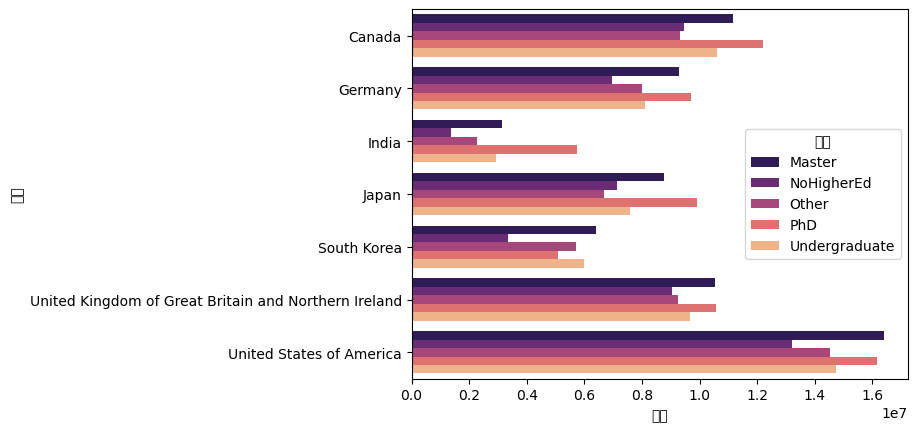

In [16]:
# 국적, 학력 기준 데이터 bar그래프 시각화
# 국적별로 데이터가 나뉘어져 있지만 분류가 너무 많아 보기 힘듦
# -> 국내 데이터에 대해서 분석이 필요하므로 South Korea 데이터만 가져오기!
sns.barplot(data=country_grade_pay, x='월급', hue='학력', y='국적', palette='magma')

<Axes: ylabel='학력'>

c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: Use

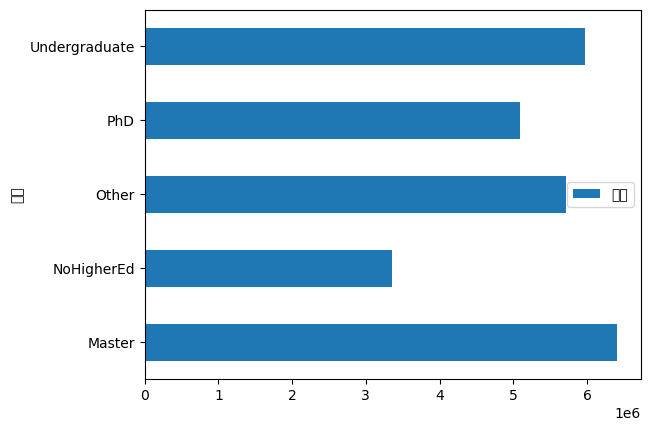

In [17]:
# country_grade_pay에서 South Korea 데이터만 가져오기
korea_grade_pay = country_grade_pay.loc['South Korea']

# bar 그래프 시각화
# DataFrame.plot 
korea_grade_pay.plot(kind='barh')

## 학력, 국적 데이터 분석 결과
>#### 분석결과
> - NoHigherEd(고등학교 졸업)의 학력을 가진 개발자의 평균 급여가 굉장히 낮게 책정되어 있음을 확인
> - Undergraduate(학사) 학력을 가진 개발자는 Master(석사), Other(기타)와 비교적 큰 차이는 없음
> - 고졸 학력을 갖고 있는 개발자는 학사까지 취득할 수 있는 방법에 대한 강구 필요

## 2) 다룰 수 있는 기술이 늘어날수록 더 많은 급여를 받을 것이다.

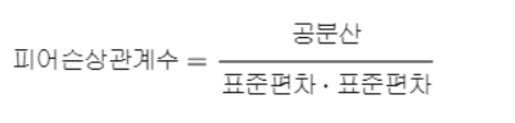

>- 표준편차 : 데이터의 분산정도를 나타낸 값
>- 공분산 : 두 특성간의 선형관계를 수치화 하여 나타낸 값
>   - 성적과 공부시간이 비례하다면 양의 공분산을 가짐
>   - 성적과 게임시간이 반비례하다면 음의 공분산을 가짐
>   - 성적과 머리카락 길이간의 연관성이 없다면 0에 가까운 공분산을 가짐
>- 상관계수 : 공분산 값을 -1 ~ 1 사이의 실수 값으로 정규화 한 값

In [18]:
# 상관계수 분석
# -> corr 함수를 활용하여 상관관계 출력
# 문자 데이터가 섞여 있는 경우, numeric_only = True 설정 필요

data.corr(numeric_only=True)

,개발공부기간,연차,연봉,보유기술개수,월급
개발공부기간,1.000000,0.902706,0.373848,-0.038932,0.373848
연차,0.902706,1.000000,0.390697,-0.034457,0.390697
연봉,0.373848,0.390697,1.000000,0.072530,1.000000
보유기술개수,-0.038932,-0.034457,0.072530,1.000000,0.072530
월급,0.373848,0.390697,1.000000,0.072530,1.000000


<Axes: >

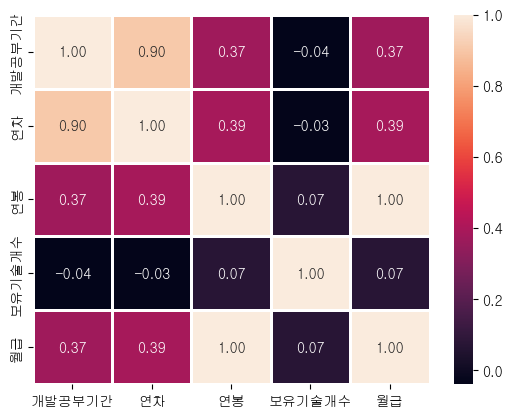

In [19]:
# heatmap 활용 상관계수 시각화
# annot : 수치를 표기할지 말지 결정하는 매개변수
# fmt : 포매팅 형식
# linewidths : 격자 선 두께
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", linewidths=1)

## 급여, 보유기술개수 데이터 분석 결과
> ### 분석 결과
> - heatmap을 봤을 때, 보유기술개수와 월급 데이터는 0.07의 상관관계를 갖고 있다.
> - 즉, 단순히 보유기술을 늘리는 것은 급여 상승에 큰 도움이 되지 않는다.


> ### 추가 행동
> - 연봉상승에 의미가 있는 특정 스킬이 있는지 분석이 필요

## 3) 연봉을 많이 받을 수 있는 특정 기술 스택이 존재할 것이다.

In [18]:
# 개발자 스킬 데이터 불러오기
skills = pd.read_csv('data/Developer Skills.csv', encoding='euc-kr', index_col='일련번호')
skills

,보유기술
일련번호,
DEV1,C;C++;Java;Perl;Ruby;Git;Ruby on Rails
DEV2,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...
DEV3,C++;HTML/CSS;Java;JavaScript;Kotlin;Node.js;Ty...
DEV4,Python;Git;PostgreSQL
DEV5,C;C++;Java;Python;Git
...,...
DEV33462,C;C#;C++;Microsoft Azure;SQLite
DEV33463,C#;HTML/CSS;JavaScript;TypeScript;Docker;Kuber...
DEV33464,C#;HTML/CSS;Java;JavaScript;npm;ASP.NET Core ;...


In [19]:
# 보유기술의 내용은 ;를 통해 사람이 임의로 구분자를 넣어준 형태로 이루어져있다.
# -> 컴퓨터는 하나의 문자열로 취급하기 때문에, 각 기술별로 분할처리 필요

# str -> Series의 문자 데이터를 일괄적으로 처리할 수 있게끔 만들어주는 기능을 제공
# split -> 문자 데이터를 특정 기준으로 분할처리 하는 함수
skill_data = skills['보유기술'].str.split(';')

skill_data

일련번호
DEV1           [C, C++, Java, Perl, Ruby, Git, Ruby on Rails]
DEV2        [Bash/Shell, HTML/CSS, JavaScript, PHP, Ruby, ...
DEV3        [C++, HTML/CSS, Java, JavaScript, Kotlin, Node...
DEV4                                [Python, Git, PostgreSQL]
DEV5                              [C, C++, Java, Python, Git]
                                  ...                        
DEV33462                [C, C#, C++, Microsoft Azure, SQLite]
DEV33463    [C#, HTML/CSS, JavaScript, TypeScript, Docker,...
DEV33464    [C#, HTML/CSS, Java, JavaScript, npm, ASP.NET ...
DEV33465    [C#, HTML/CSS, JavaScript, SQL, TypeScript, np...
DEV33466                                     [Python, Docker]
Name: 보유기술, Length: 33466, dtype: object

In [20]:
# skill_data 안에 list 형태의 데이터가 삽입 된 것을 확인

# explode 함수 -> 리스트 형태의 데이터를 다수의 행으로 전개하는 기능을 제공
# 리스트 안의 요소 개수만큼 행이 증식된다!

explode_skill = skill_data.explode()

explode_skill

일련번호
DEV1                           C
DEV1                         C++
DEV1                        Java
DEV1                        Perl
DEV1                        Ruby
                    ...         
DEV33465                DynamoDB
DEV33465    Microsoft SQL Server
DEV33465                  SQLite
DEV33466                  Python
DEV33466                  Docker
Name: 보유기술, Length: 442784, dtype: object

In [21]:
# 데이터 형태 확인 
# -> 약 33,000개 데이터가 440,000개 정도로 늘어난 것을 확인
explode_skill.shape

(442784,)

In [22]:
# 전처리 후에 결측치가 존재 하는지 확인
# -> 28개의 결측치가 존재
# 개발자 데이터와 병합 후, 어떤 데이터가 결측치인지 확인 필요
explode_skill.isnull().sum()

np.int64(28)

In [23]:
# how : inner, outer, left, right 조인 방식 결정
# on : 어떤 특성을 기준으로 병합할지 결정

full_data = pd.merge(explode_skill, data, how='inner', on='일련번호')

full_data

,보유기술,나이,학력,성별,정신건강,전문직,개발공부기간,연차,국적,연봉,보유기술개수,월급
일련번호,,,,,,,,,,,,
DEV1,C,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9390735
DEV1,C++,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9390735
DEV1,Java,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9390735
DEV1,Perl,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9390735
DEV1,Ruby,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9390735
...,...,...,...,...,...,...,...,...,...,...,...,...
DEV33465,DynamoDB,<35,Undergraduate,Man,Yes,Dev,5,1,United States of America,70000,15,8505000
DEV33465,Microsoft SQL Server,<35,Undergraduate,Man,Yes,Dev,5,1,United States of America,70000,15,8505000
DEV33465,SQLite,<35,Undergraduate,Man,Yes,Dev,5,1,United States of America,70000,15,8505000


In [24]:
# 결측치 데이터 조회
# (실습) 결측치가 존재하는 개발자 데이터를 조회 후, 왜 결측치가 비어있는지 유추하기
# -> 보유기술개수 컬럼에 0이라는 값이 들어있는 것을 보아, 보유기술을 따로 기입하지 않아서 결측치가 삽입 된 것을 확인
full_data[full_data['보유기술'].isnull()]

# nan값을 -> 없음이라는 값으로 채워주기

full_data['보유기술'] = full_data['보유기술'].fillna('없음')

full_data[full_data['보유기술'].isnull()]


,보유기술,나이,학력,성별,정신건강,전문직,개발공부기간,연차,국적,연봉,보유기술개수,월급
일련번호,,,,,,,,,,,,


In [25]:
# South Korea에 한해서 보유기술별로 평균 월급 계산하기
# -> groupby, pivot, boolean 인덱싱 활용

country_skill_pay = full_data[['국적', '보유기술', '월급']].groupby(['국적', '보유기술']).median()

# 지수표기법으로 나오니까 정수형으로 형변환
korea_skill_pay = country_skill_pay.loc['South Korea'].astype(int)

# 보유기술의 abc순으로 출력되고 있음
# -> 월급 기준으로 내림차순 하기!
# 상위권에 우리가 전혀 모르는 언어가 존재하고 있음
# -> 오래된 기술이고, 이 기술을 익히고 있는 사람은 연차가 높은 경우가 많을 것임
# 연차를 5년 미만으로 제한하여 다시 확인해보자!

korea_skill_pay.sort_values(by='월급', ascending=False).head(10)

,월급
보유기술,
Couchbase,17311077
Clojure,15279475
Puppet,11540070
Cassandra,10963734
Linode,10579005
Terraform,10098168
Neo4j,9617332
OCaml,9617332
Go,9617332


<Axes: ylabel='보유기술'>

c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\smhrd\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 44553 (\N{HANGUL S

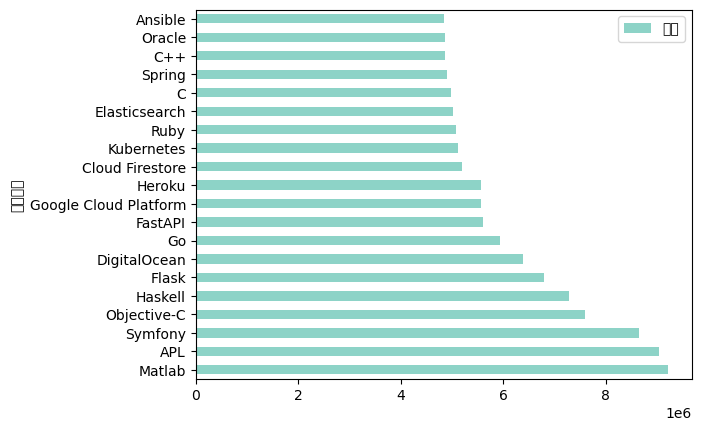

In [26]:
# 연차가 5년 미만인 개발자 데이터만 가져오기
junior_data = full_data[full_data['연차'] < 5]

# 국적과 보유기술 기준 그룹화
junior_skill_pay = junior_data[['보유기술', '월급', '국적']].groupby(['국적','보유기술']).mean().astype(int)


# 생소한 기술들도 많지만 Flask, Go, FastAPI, C언어 등, 많이 쓰이는 기술이 보임 
# head 함수를 통해 상위 20개 기술 가져오기
twenty_skills = junior_skill_pay.loc['South Korea'].sort_values(by='월급', ascending=False).head(20)

# barh 그래프 시각화
twenty_skills.plot(kind='barh', colormap='Set3')

## 학력, 국적 데이터 분석 결과

> ### 분석 결과
> - Matlab, Flask, FastAPI, Go, Firebase 등의 언어를 가진 개발자의 급여가 높개 책정되어 있음
> - 주로 데이터 분석 계열의 기술 스택과 Cloud 서비스 계열 기술의 급여가 높은 편

## 분석결과 종합
#### 학력, 국적 데이터 분석 결과
> - NoHigherEd(고등학교 졸업)의 학력을 가진 개발자의 평균 연봉이 굉장히 낮게 책정되어 있음을 확인
> - Undergraduate(학사) 학력을 가진 개발자는 Master(석사), Other(기타)와 비교적 큰 차이는 없음
> - 고졸 학력을 갖고 있는 박인재는 학사까지 취득할 수 있는 방법에 대한 강구 필요
#### 급여, 보유기술개수 데이터 분석 결과
> - 보유기술개수와 월급 데이터간의 선형관계를 Scatter로 파악했을 땐 뚜렷하게 선형관계가 있어 보이진 않음
> - heatmap을 봤을 때, 보유기술개수와 월급 데이터는 0.07의 상관관계를 갖고 있다.
> - 즉, 단순히 보유기술을 늘리는 것은 연봉 상승에 큰 도움이 되지 않는다.
#### 학력, 국적 데이터 분석 결과
> - Matlab, Flask, FastAPI, Go, Firebase 등의 언어를 가진 개발자의 급여가 높게게 책정되어 있음
> - 주로 데이터 분석 계열의 기술 스택과 Cloud 서비스 계열 기술의 급여가 높은 편

## 인사이트 도출
#### 학력에 따른 연봉 차이
>- 고졸 개발자는 평균연봉이 낮다.
>- 하지만 학사와 석사의 차이는 상대적으로 크지 않다.
>- 학위보다는 실무 기술 역량이 더 큰 영향을 미칠 수 있음
>- 그러나 고졸은 최소 학사 수준으로 신뢰도 보완 필요.
#### 기술 수 vs 연봉 관계
>- 보유 기술 개수와 연봉의 상관관계는 매우 약함(0.07)
>- 단순히 많이 아는 것보다, 핵심 기술을 정밀하게 다룰줄 아는 것이 중요.
>- 즉, 기술의 깊이와 실용성이 더 큰 변수.
#### 기술 스택별 연봉 편차
>- Matlab, FastAPI, Firebase, Go 등 -> 연봉이 높은 기술군.
>- 이는 데이터 분석, 인공지능, 클라우드 서비스 연관 기술이 연봉 성장에 기여

## 페르소나
- 우리 서비스를 사용할 전형적인 사용자를 대표하는 가상의 인물
- 데이터를 기반으로 구체적인 속성 부여
>- 기본 정보(이름, 나이, 성별)
>- 배경 및 서사(전공 여부, 학력 수준 등)
>- 문제 인식
>- 동기와 목표(분석의 필요성, 해결하고 싶은 질문 등)
- 페르소나의 이점
>- 사용자 중심의 의사결정 : 기획자의 주관이 아닌 페르소나의 니즈에 집중할 수 있음
>- 팀원 간의 공통된 이해 : 동일한 타겟 사용자를 머릿속에 그리며 소통할 수 있음
>- 기능의 우선순위 선정 : 페르소나의 문제를 해결하는 기능을 최우선으로 배정, 서비스의 본질 유지
>- 데이터의 해석 구체화 : 막연한 데이터에 맥락을 입혀 서비스 구현에 영감을 줄 수 있음

## 🧍‍♂️ 페르소나 정의

#### 페르소나 작성 템플릿

### 1. 기본 정보
- **이름**: *(가명 가능)*  
- **나이**:   
- **성별**: *(선택)*  

---

### 2. 배경 및 상황
- **전공 여부**: *(전공 / 비전공)*  
- **학력 수준**: *(고졸 / 학사 / 석사 / 기타)*  
- **현재 상태**: *(예: 부트캠프 수강 중 / 수료 후 신입 개발자 / 이직 준비 중 등)*  

---

### 3. 현재 역할 또는 학습 영역
- **집중 중인 기술 분야**: *(예: 프론트엔드, 백엔드, 데이터, AI 등)*  
- **실습 중 흥미를 느낀 기술**: *(선택적으로 작성)*  

---

### 4. 문제 인식 및 고민
- **현재 느끼는 커리어 관련 고민**:  
  *(예: 연봉이 낮다, 내가 어떤 기술을 더 배워야 할지 모르겠다, 회사 내 성장이 어렵다 등)*  

- **기존에 겪은 불만족스러운 경험**:  
  *(예: 직무 미스매치, 기술 격차, 기대 연봉과의 차이 등)*  

---

### 5. 동기와 니즈
- **왜 분석을 하게 되었는가?**  
  *(이 분석이 본인에게 왜 필요한가)*  

- **현재 가장 알고 싶은 것 또는 해결하고 싶은 질문**  
  *(예: 어떤 기술이 연봉에 유리한가? 나와 유사한 사람은 어떤 경로로 성장했는가? 등)*  

---

### 6. 성향 및 학습 스타일
- **학습 스타일**: *(자기주도 학습 / 실습 중심 / 피드백 중심 등)*  
- **의사결정 방식**: *(데이터 기반 / 직관 기반 / 경험 기반 등)*  

---

### 7. 목표
- **단기 목표 (3~6개월)**:  
  *(예: 포트폴리오 완성, 실무 기술 학습, 프로젝트 참여 등)*  

- **장기 목표 (1~2년)**:  
  *(예: 연봉 1.5배 성장, 이직 성공, 특정 분야 전문가 등)*  


### 1. 기본 정보
- **이름**: 박인재  
- **나이**:   29
- **성별**: 남  

---

### 2. 배경 및 상황
- **전공 여부**: 비전공  
- **학력 수준**: 고졸
- **현재 상태**: AI Agent 과정 수료 후 신입 개발자로 취업

---

### 3. 현재 역할 또는 학습 영역
- **집중 중인 기술 분야**: AI 모델링
- **실습 중 흥미를 느낀 기술**: Python, Python Library

---

### 4. 문제 인식 및 고민
- **현재 느끼는 커리어 관련 고민**:  
  연봉이 낮아서 내가 어떤 기술을 더 배워야 할지 모르겠다  

- **기존에 겪은 불만족스러운 경험**:  
  기대 연봉과의 차이  

---

### 5. 동기와 니즈
- **왜 분석을 하게 되었는가?**  
  이직 또는 업무 분장을 통해 새로운 기술 스택을 경험  

- **현재 가장 알고 싶은 것 또는 해결하고 싶은 질문**  
  어떤 기술이 연봉에 유리한가?  

---

### 6. 성향 및 학습 스타일
- **학습 스타일**: 자기주도 학습  
- **의사결정 방식**: 데이터 기반  

---

### 7. 목표
- **단기 목표 (3~6개월)**:  
  실무 기술 학습  

- **장기 목표 (1~2년)**:  
  연봉 1.5배 성장  

## 💡 솔루션 도출 – DevGrow

### 🎯 목표  
부트캠프 수료자 등 신입 개발자가 현실적인 연봉과 커리어 성장의 간극을 인식하고,  
데이터 기반으로 **자기 진단 → 전략 수립 → 실행 로드맵 생성**까지 할 수 있도록 돕는 솔루션

---

### 📌 솔루션명  
**DevGrow**  
_데이터 기반 경력 설계와 연봉 성장 전략 플랫폼_

---

## 🔧 주요 기능 구성

| 기능 구분 | 기능 설명 | 기대 효과 |
|-----------|-----------|------------|
| **1. 개인 입력 기반 진단** | 사용자가 `학력`, `경력`, `보유 기술`, `국적` 등을 입력하면 유사한 현업 개발자 군과 연봉 비교 | 현실 기반 자기 위치 파악 |
| **2. 기술-연봉 영향도 분석** | FastAPI, Firebase, Go 등 기술별 연봉 기여도 시각화 | 투자 대비 수익 높은 기술 우선 학습 |
| **3. 경력 시뮬레이션** | `기술 2개 추가`, `학위 취득`, `이직` 등 시나리오별 연봉 변화 시뮬레이션 | 연봉 성장 가능성 예측 |
| **4. 개인 맞춤형 로드맵 생성** | 현재 위치와 목표를 기반으로 한 기술 학습 순서 및 프로젝트 제안 | 실행 가능한 커리어 로드맵 제공 |
| **5. PDF 기반 성장 리포트 출력** | 위 결과를 요약해 이력서, 포트폴리오 등에 첨부 가능한 리포트로 자동 출력 | 경력 관리 자료로 활용 가능 |
